## SARIMA Model

SARIMA = ARIMA + Seasonality



### Example:
Monthly sales with yearly repeating pattern



### Key Idea:
Handles repeating seasonal patterns


<img src="SARIMA_working.png" alt="Time Series info" width="900" height="600" />


In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Load the Highly Seasonal Dataset

print("--- Fetching Seasonal Temperature Data ---")
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

# Load dataset and convert daily data into monthly average values
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
df_monthly = df.resample('M').mean()  # 'M' means month-end frequency

# Rename column for better understanding
df_monthly.rename(columns={'Temp': 'Temperature'}, inplace=True)

print(f"Total Monthly Data Points: {len(df_monthly)}")

--- Fetching Seasonal Temperature Data ---
Total Monthly Data Points: 120


In [12]:
df_monthly

,Temperature
Date,
1981-01-31,17.712903
1981-02-28,17.678571
1981-03-31,13.500000
1981-04-30,12.356667
1981-05-31,9.490323
...,...
1990-08-31,7.825806
1990-09-30,9.166667
1990-10-31,11.345161


In [5]:
# Train-Test Split

# Total data is around 120 months (10 years)
# First 96 months (8 years) for training and last 24 months (2 years) for testing
train_data = df_monthly.iloc[:96]
test_data = df_monthly.iloc[96:]

print(f"Training months: {len(train_data)}, Testing months: {len(test_data)}\n")

Training months: 96, Testing months: 24



In [13]:
train_data

,Temperature
Date,
1981-01-31,17.712903
1981-02-28,17.678571
1981-03-31,13.500000
1981-04-30,12.356667
1981-05-31,9.490323
...,...
1988-08-31,8.725806
1988-09-30,9.883333
1988-10-31,10.890323


### seasonal_order=(1, 1, 1, 12) defines how the SARIMA model handles yearly seasonal patterns.
* 12 (s) tells the model that the data repeats every 12 months.
* 1 (P) uses information from the same season in the previous year for prediction.
* 1 (D) removes long-term trends by comparing current data with last year’s data.
* 1 (Q) adjusts predictions using past seasonal forecasting errors.

In [ ]:
# SARIMA Robust Rolling Forecast

print("--- Starting SARIMA Rolling Forecast ---")

history = list(train_data['Temperature'])
predictions = []

for t in range(len(test_data)):
    try:
        # Check variance to avoid mathematical errors
        if np.var(history) == 0:
            yhat = history[-1] 
        else:          
            
            # SARIMA model configuration
            model = SARIMAX(history, 
                            order=(1, 0, 1), 
                            seasonal_order=(1, 1, 1, 12),
                            
                            # By setting this to False, we are telling the model to relax its strict 
                            # mathematical rules. This prevents the code from breaking during the 
                            # loop if the data gets a little messy.
                            enforce_stationarity=False, 
                            
                            # Just like stationarity, "invertibility" is a strict math rule related to 
                            # how the model calculates its errors.
                            # Setting this to False acts as a safety net. It allows the model to keep 
                            # running and give you the best possible prediction instead of just giving up 
                            # and throwing an error.
                            enforce_invertibility=False)
            
            # FIX: Removed unsupported 'innovations_mle' method
            # Using default solver (lbfgs), which is stable for SARIMA
            # the "engine" under the hood that does the heavy math. lbfgs is the 
            # name of a specific mathematical solver (optimizer)
            fitted_model = model.fit(method = 'lbfgs', disp=False)
            
            
            # Forecast the next month's value
            yhat = fitted_model.forecast(steps=1)[0]
            
    except Exception as e:
        print(f"Warning at step {t}: {e}")
        # Fallback: use last observed value
        yhat = history[-1]

    predictions.append(yhat)
    
    # Update history with the actual observed value
    obs = test_data['Temperature'].iloc[t]
    history.append(obs)
    
    if t % 6 == 0:
        print(f"Month {t}: Predicted Temp={yhat:.2f}°C, Actual Temp={obs:.2f}°C")

predictions_series = pd.Series(predictions, index=test_data.index)


--- Starting SARIMA Rolling Forecast ---
Month 0: Predicted Temp=14.87°C, Actual Temp=15.18°C
Month 6: Predicted Temp=6.42°C, Actual Temp=6.33°C
Month 12: Predicted Temp=14.96°C, Actual Temp=15.58°C
Month 18: Predicted Temp=6.91°C, Actual Temp=8.18°C


### The Importance of a Rolling Forecast

Why did we use a rolling forecast instead of predicting all 24 months at once?

Imagine driving a car at night. You don't try to memorize the entire 100-mile highway before you start driving. You look at what your headlights illuminate right in front of you, drive forward, look again, and adjust your steering.

A rolling forecast works the exact same way. The model predicts just one month ahead, waits to see what the actual temperature was for that month, adds that new reality to its memory, and only then predicts the next month. It constantly updates itself with fresh data. This is crucial because it mimics how real-world businesses, factories, and weather stations actually predict the future.

In [7]:
# Evaluation

mse = mean_squared_error(test_data['Temperature'], predictions)
print(f"\nMean Squared Error (MSE): {mse:.2f}")


Mean Squared Error (MSE): 0.60


Our model scored a Mean Squared Error (MSE) of 0.60. By itself, 0.60 is just a math number. But if we take the square root of it, we get about 0.77.

This means our model's predictions were only wrong by an average of 0.77°C. When you are looking at weather that jumps anywhere between 13°C and 25°C, missing the true temperature by less than one single degree is an incredibly accurate and powerful result.

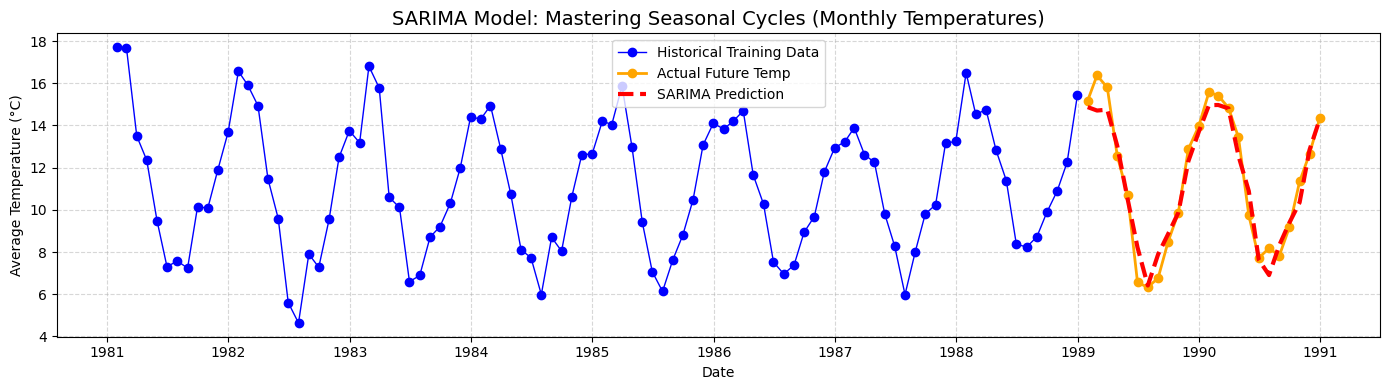

In [10]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(14, 4))

# Historical training data
plt.plot(train_data.index, train_data['Temperature'],
         marker='o', linestyle='-',
         color='blue', linewidth=1,
         label='Historical Training Data')

# Actual future values
plt.plot(test_data.index, test_data['Temperature'],
         marker='o', linestyle='-',
         color='orange', linewidth=2,
         label='Actual Future Temp')

# SARIMA predicted values
plt.plot(test_data.index, predictions_series,
         linestyle='--',
         color='red', linewidth=3,
         label='SARIMA Prediction')

# Labels and title
plt.title('SARIMA Model: Mastering Seasonal Cycles (Monthly Temperatures)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

### How to Understand the Graph

If you look at the chart, it is a visual map of our model's brain.

The bottom axis shows the passing years, and the left side shows the Average Temperature in Celsius.

The solid blue line is the historical data. Notice how it goes up and down in perfect waves? That is the heartbeat of the seasons—summer peaks and winter valleys repeating over the 8 years.

On the far right, you see the orange line. This is what actually happened during the 2 years we hid from the model.

The red dashed line is our model's prediction for those 2 years. The true proof that our project worked is that the red dashed line sits almost perfectly on top of the orange line. It learned the rhythm!

## What we did ##

- Collected daily temperature data and converted it into 120 monthly average values.
- Used the first 96 months for training and kept the last 24 months for testing.
- Built a SARIMA model with a seasonal cycle of 12 months to capture yearly weather patterns.
- Predicted the hidden 2 years using rolling forecasts and evaluated the model’s accuracy.

<div style="text-align: center; font-size: 16px;">
<b>Created by</b><br>
Priyanka Deore & Kunal Mahadule
</div>